> Pedro J. Torres-González

> z32togop@uco.es
# Taller: APIs, Datos Abiertos y Python

Bienvenido al cuaderno práctico del taller.

## Qué vamos a hacer
- Entender qué es una API y cómo pedir datos.
- Leer respuestas en formato JSON.
- Crear pequeños programas en Python con datos reales.
- Resolver un reto final con una API a tu elección.

## Cómo usar este cuaderno
- Ejecuta cada celda con Shift+Enter.
- Si algo falla, revisa primero el mensaje de error.
    - Puedes pasarle el error a la IA para que te explique y corrija el código.
- No hace falta entender todo a la primera: prueba, cambia cosas y vuelve a ejecutar.

## Niveles
- Nivel 1: ejecutar celdas guiadas y cambiar parámetros.
- Nivel 2: recorrer JSON y escribir funciones.
- Nivel 3: crear un mini proyecto con lógica propia y, si quieres, gráficos.

In [1]:
import json
import sys

import requests

print("Entorno listo")
print("Versión de Python:", sys.version.split()[0])

Entorno listo
Versión de Python: 3.12.3


## Sección 1. Primera llamada a una API

🔹 Recomendado para Nivel 1

En este primer ejemplo vamos a pedir información de un Pokémon a la PokeAPI.

Recuerda la idea principal:
- Cliente: nuestro cuaderno.
- Servidor: la API.
- Respuesta: un JSON con datos.

In [6]:
# Definimos primero la URL de la API que queremos consultar (endpoint)
pokemon = "pikachu" # Puedes cambiarlo por cualquier otro Pokémon
url = f"https://pokeapi.co/api/v2/pokemon/{pokemon}"

# Guardamos la respuesta de la API en una variable para poder consultarla después
respuesta = requests.get(url)

print("Código de estado:", respuesta.status_code,"\n") # si el codigo es 200, la consulta ha sido exitosa, en caso contrario, ha habido un error
datos = respuesta.json()

print("Nombre:", datos["name"])
print("Peso:", datos["weight"])
print("Tipo principal:", datos["types"][0]["type"]["name"])

Código de estado: 200 

Nombre: pikachu
Peso: 60
Tipo principal: electric


### Mini retos de esta sección

- Reto 1: cambia `pikachu` por otro Pokémon y vuelve a ejecutar la celda anterior.
- Reto 2: intenta imprimir también su altura con `datos["height"]`.
- Pregunta guía: ¿qué parte del código está haciendo realmente la petición a internet?

## Sección 2. Entender y navegar un JSON

🔹 Recomendado para Nivel 1-2

Una respuesta JSON suele convertirse en Python en diccionarios y listas anidadas.

Piensa en esta estructura:
- llaves `{}`: diccionario
- corchetes `[]`: lista
- claves: palabras como `name`, `types` o `moves`

Antes de ejecutar la siguiente celda, intenta predecir qué tipo de dato hay dentro de `datos["moves"]`.

In [24]:
# Imprimimos las claves principales del diccionario para entender su estructura y saber que informacion nos devuelve la API
print("Claves principales:", datos.keys())

print("\nTipo principal:")
print(datos["types"][0]["type"]["name"])

print("\nPrimeros 5 movimientos:")
for movimiento in datos["moves"][:5]:
    print("-", movimiento["move"]["name"])

print("\nNúmero total de movimientos:", len(datos["moves"]))


Claves principales: dict_keys(['abilities', 'base_experience', 'cries', 'forms', 'game_indices', 'height', 'held_items', 'id', 'is_default', 'location_area_encounters', 'moves', 'name', 'order', 'past_abilities', 'past_stats', 'past_types', 'species', 'sprites', 'stats', 'types', 'weight'])

Tipo principal:
electric

Primeros 5 movimientos:
- mega-punch
- pay-day
- thunder-punch
- slam
- double-kick

Número total de movimientos: 105


### Reto

Modifica la celda anterior para explorar más datos del Pokémon:

- Reto 1: Imprime el **segundo tipo** del Pokémon si tiene más de uno .
- Reto 2: Imprime el **movimiento número 10** en lugar de los 5 primeros (pista: cambia el `[:5]` por `[9]`).
- Reto 3: ¿En que zonas puedo encontrar ese pokemon?
<details>
<summary>Pista (haz clic para ver)</summary>

Pista1: fíjate en qué parte del código solo tienes que cambiar un número o un nombre.

Pista2: ```datos["types"][0]["type"]["name"]``` contiene el Nombre del primer tipo del pokemon, ¿que habría que cambiar para que mostrara el siguiente...?
</details>


## Sección 3. Funciones y reutilización

🔷 Recomendado para Nivel 2

Si tenemos que hacer la misma petición varias veces, no conviene copiar y pegar código.

Una función nos permite:
- recibir un dato de entrada
- hacer la petición
- procesar la respuesta
- devolver un resumen legible

In [8]:
def buscar_pokemon(nombre):
    url = f"https://pokeapi.co/api/v2/pokemon/{nombre.lower()}"
    respuesta = requests.get(url)

    if respuesta.status_code == 200:
        datos = respuesta.json()
        tipo = datos["types"][0]["type"]["name"]
        peso_kg = datos["weight"] / 10
        num_movimientos = len(datos["moves"])
        resumen = (
            f"{nombre.capitalize()} | Tipo: {tipo} | "
            f"Peso: {peso_kg} kg | Movimientos: {num_movimientos}"
        )
        return resumen

    return f"Pokémon '{nombre}' no encontrado."

print(buscar_pokemon("bulbasaur"))
print(buscar_pokemon("charmander"))
print(buscar_pokemon("squirtle"))
print(buscar_pokemon("mew"))

Bulbasaur | Tipo: grass | Peso: 6.9 kg | Movimientos: 86
Charmander | Tipo: fire | Peso: 8.5 kg | Movimientos: 105
Squirtle | Tipo: water | Peso: 9.0 kg | Movimientos: 105
Mew | Tipo: psychic | Peso: 4.0 kg | Movimientos: 375


## Sección 4. El patrón se repite con otras APIs

🔹🔷 Recomendado para Nivel 1-2

La idea importante es esta: una vez entiendes el patrón `requests.get(...) -> .json() -> acceder a datos`, puedes reutilizarlo con muchas APIs distintas.

In [10]:
url_chiste = "https://official-joke-api.appspot.com/random_joke"
respuesta_chiste = requests.get(url_chiste)
chiste = respuesta_chiste.json()

print("Setup:", chiste["setup"])
print("Punchline:", chiste["punchline"])


def contar_chistes(n):
    for indice in range(1, n + 1):
        respuesta = requests.get(url_chiste)
        chiste = respuesta.json()
        print(f"\nChiste {indice}:")
        print(chiste["setup"])
        print(chiste["punchline"])


contar_chistes(2)

Setup: What’s the advantage of living in Switzerland?
Punchline: Well, the flag is a big plus.

Chiste 1:
Have you heard of the band 1023MB?
They haven't got a gig yet.

Chiste 2:
Did you hear about the cow who jumped over the barbed wire fence?
It was udder destruction.


Nombre: Spain
Capital: Madrid
Población: 49315949
Región: Europe
Bandera: https://flagcdn.com/w320/es.png


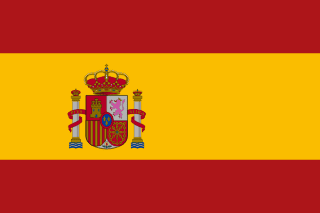

In [14]:
pais="spain"
url_paises = f"https://restcountries.com/v3.1/name/{pais}"
r = requests.get(url_paises)
paises = r.json()

pais = paises[0]
print("Nombre:", pais["name"]["common"])
print("Capital:", pais["capital"][0])
print("Población:", pais["population"])
print("Región:", pais["region"])
print("Bandera:", pais["flags"]["png"])

#Código para mostrar la imagen de la bandera del país
from PIL import Image
from IPython.display import display
import requests
from io import BytesIO
# Volvemos a hacer una consulta para descargar la imagen de la bandera del país
response = requests.get(pais["flags"]["png"])
img = Image.open(BytesIO(response.content))
display(img)


### Ideas de extensión

- Cambia `spain` por otro país.
- Intenta mostrar también la subregión o la moneda.
- Explica con tus palabras qué partes del código son iguales entre PokeAPI, la API de chistes y REST Countries.

## Sección 5. APIs con parámetros

🔷🔶 Recomendado para Nivel 2-3

Muchas APIs no cambian el endpoint principal, sino que reciben parámetros para filtrar resultados.

En Python, la forma más cómoda suele ser usar `requests.get(url, params=parametros)`.

## Open-Meteo

In [15]:
url_meteo = "https://api.open-meteo.com/v1/forecast"

parametros = {
    "latitude": 37.91497799015475,
    "longitude": -4.717000716657287,
    "hourly": "temperature_2m",
    "forecast_days": 1,
}

r = requests.get(url_meteo, params=parametros)
meteo = r.json()

print("Claves principales:", meteo.keys())
print("\nPrimeras 5 horas de temperatura:")
horas = meteo["hourly"]["time"][:5]
temps = meteo["hourly"]["temperature_2m"][:5]
for hora, temperatura in zip(horas, temps):
    print(hora, "->", temperatura, "ºC")

Claves principales: dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])

Primeras 5 horas de temperatura:
2026-04-15T00:00 -> 13.5 ºC
2026-04-15T01:00 -> 13.0 ºC
2026-04-15T02:00 -> 12.4 ºC
2026-04-15T03:00 -> 11.5 ºC
2026-04-15T04:00 -> 10.8 ºC


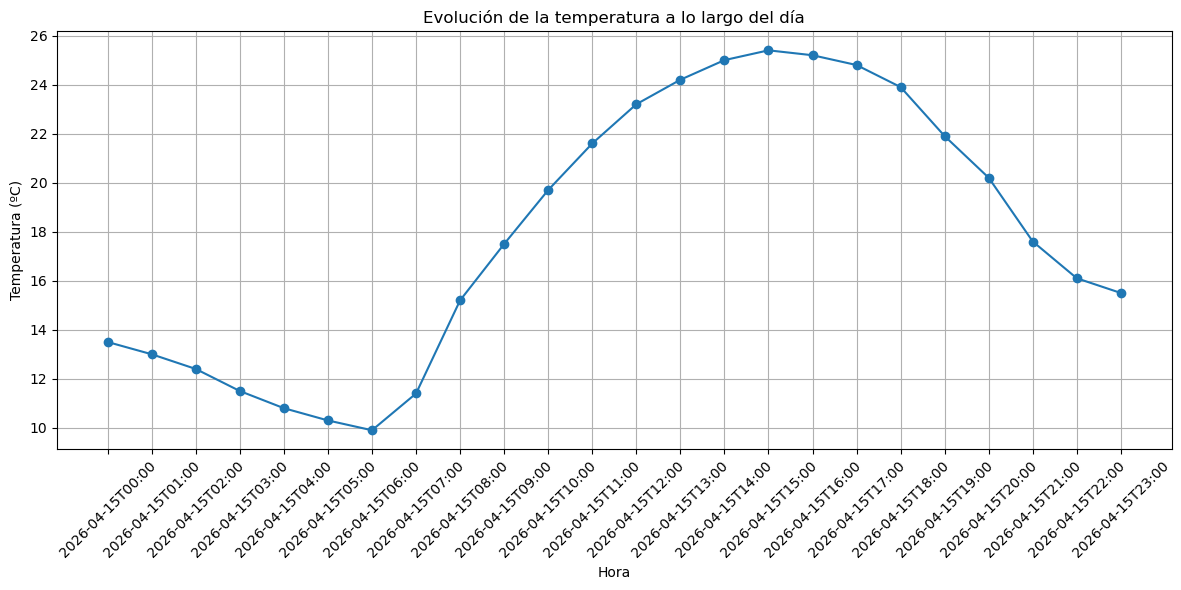

In [ ]:
# Extraemos los datos de temperatura y hora para el día completo y creamos un dataframe con ellos
import pandas as pd
df_meteo = pd.DataFrame({
    "Hora": meteo["hourly"]["time"],
    "Temperatura (ºC)": meteo["hourly"]["temperature_2m"]
})

# hacemos un gráfico de la evolución de la temperatura a lo largo del día
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df_meteo["Hora"], df_meteo["Temperatura (ºC)"], marker="o")
plt.xticks(rotation=45)
plt.title("Evolución de la temperatura a lo largo del día")
plt.xlabel("Hora")
plt.ylabel("Temperatura (ºC)")
plt.grid()
plt.tight_layout()
plt.show()

### Reto Nivel 3
- Consulta la web de [Open-Meteo](https://open-meteo.com/en/docs), donde puedes usar su API desde el navegador, investiga que otras variables puedes pedir y rellena la siguiente celda para representar otra variable.

In [ ]:
# Definicion del endpoint y los parametros para la consulta a la API
url_meteo = "https://api.open-meteo.com/v1/forecast"

parametros = {
    "latitude": 37.91497799015475,
    "longitude": -4.717000716657287,
    # TO DO: Añade el nuevo parametro o parametros que quieras consultar de la API
    
}

r = requests.get(url_meteo, params=parametros)
meteo = r.json()

df_meteo = pd.DataFrame({
    "Hora": meteo["hourly"]["time"],
    # TO DO:  Añade la nueva variable que has obtenido de la API al dataframe
   
})

plt.figure(figsize=(12, 6))
plt.plot(df_meteo["Hora"], df_meteo[], marker="o") # TO DO: Añade la variable nueva para ser representada
plt.xticks(rotation=45)
plt.title("Evolución de la temperatura a lo largo del día")
plt.xlabel("Hora")
plt.ylabel("Temperatura (ºC)")
plt.grid()
plt.tight_layout()
plt.show()

## Sección extra. APIs de la NASA: EPIC + Mars Weather

En este bloque vamos a usar dos APIs:

- **EPIC (NASA)**: imágenes de la Tierra tomadas desde el satélite DSCOVR.
- **Mars Weather API**: datos meteorológicos en Marte.

La idea es la misma que en todo el taller:
`requests.get(...) -> .json() -> acceder a datos`.


In [32]:
from IPython.display import Image as IPImage, display

# ==============================
# 1) API EPIC (NASA)
# ==============================
api_key_nasa = "FExIH3kWB0rE2pJcrKRh85kRugOB7NKO3J93nyvd"  # Si tienes clave propia de NASA, ponla aqui
url_epic = "https://api.nasa.gov/EPIC/api/natural"

r_epic = requests.get(url_epic, params={"api_key": api_key_nasa})

if r_epic.status_code == 200:
    datos_epic = r_epic.json()
    print(f"EPIC: {len(datos_epic)} imagenes encontradas")

    if datos_epic:
        # Cogemos la primera imagen para mostrar un ejemplo sencillo
        primera = datos_epic[6]  # Puedes cambiar el indice para mostrar otra imagen diferente
        fecha = primera["date"][:10]  # formato YYYY-MM-DD
        anio, mes, dia = fecha.split("-")
        nombre_imagen = primera["image"]

        url_img_epic = (
            f"https://api.nasa.gov/EPIC/archive/natural/{anio}/{mes}/{dia}/png/"
            f"{nombre_imagen}.png?api_key={api_key_nasa}"
        )

        print("Primera imagen EPIC:")
        print("Fecha:", fecha)
        print("Caption:", primera.get("caption", "Sin descripcion"))
        display(IPImage(url=url_img_epic, width=450))
    else:
        print("EPIC no devolvio imagenes.")
else:
    print("Error consultando EPIC:", r_epic.status_code)


# ============================================
# 2) Mars Weather Service API (MAAS)
# ============================================
url_mars_weather = "https://api.maas2.apollorion.com/"
r_mars = requests.get(url_mars_weather)

if r_mars.status_code == 200:
    mars = r_mars.json()
    print("\nTiempo en Marte (MAAS):")
    print("Fecha:", mars.get("terrestrial_date", "N/D"))
    print("Sol:", mars.get("sol", "N/D"))
    print("Temperatura minima:", mars.get("min_temp", "N/D"), "ºC")
    print("Temperatura maxima:", mars.get("max_temp", "N/D"), "ºC")
    print("Presion:", mars.get("pressure", "N/D"))
    print("Estacion:", mars.get("season", "N/D"))
else:
    print("Error consultando Mars Weather API:", r_mars.status_code)


EPIC: 12 imagenes encontradas
Primera imagen EPIC:
Fecha: 2026-04-13
Caption: This image was taken by NASA's EPIC camera onboard the NOAA DSCOVR spacecraft



Tiempo en Marte (MAAS):
Fecha: 2023-02-14
Sol: 3742
Temperatura minima: -77 ºC
Temperatura maxima: -25 ºC
Presion: 827
Estacion: Month 1


## Sección 6. Desafío final

🔶 Recomendado para Nivel 3

Ahora es tu turno. Elige una API y construye un pequeño programa propio. Usa Gemini para ayudarte a escribir código, pregunta si tienes alguna duda!!

### APIs sugeridas
- PokeAPI
- Official Joke API
- Open-Meteo
- REST Countries
- Nasa API
- Hay rienda suelta para usar cualquier otra API que conozcas o explorar en la web otras.

### Objetivo del desafío
El objetivo de este reto es interiorizar lo aprendido, dejar rienda suelta a la creatividad y tener un primer acercamiento al uso de APIS con la intención de crear algún servicio. 

Aqui te dejo algunas ideas:

- Visualizador de temperatura
- Wiki de Pokemon / Rick y Morty / Paises
- Explorador de curiosidades del espacio (APIS Nasa)
- ...



<details>
<summary><b>💡 Consejos</b></summary>

<div style="padding: 10px; font-size: 0.95em; line-height: 1.6;">

<ol>
<li><strong>Elige una API</strong> para trabajar con ella</li>
<li><strong>Piensa en utilidades</strong> que puedas desarrollar con esa API</li>
<li><strong>Piensa en la lógica</strong> del código:
<strong>Ejemplo:</strong>
  <ol style="margin-top: 8px; margin-left: 20px;">
    <li>Hacer la petición</li>
    <li>Elegir los datos necesarios de la respuesta</li>
    <li>Mostrarlos por pantalla</li>
  </ol>
<li><strong>Empieza de forma simple</strong>, probando cada parte paso a paso (Puedes pedirle a la IA que te haga una versión básica)</li>
<li><strong>Ve escalando</strong> tu código si necesitas más complejidad, ajusta los detalles finales</li>
</ol>

</div>

</details>


In [ ]:
#################
# E J E M P L O #
#################
"""

API elegida: PokeAPI (https://pokeapi.co/)
Objetivo de mi programa: Permitir al usuario consultar información de varios Pokémon a la vez, eligiendo qué datos quiere ver de cada uno (tipo, peso, número de movimientos, etc).
Entrada que pedirá al usuario: Una lista de nombres de Pokémon y una lista de datos que quiere consultar (por ejemplo: "tipo", "peso", "movimientos").
Salida esperada: Un resumen para cada Pokémon con la información solicitada, por ejemplo: "Pikachu | Tipo: eléctrico | Peso: 6 kg | Movimientos: 78".
"""

# 1) Definir los Pokémon que queremos explorar
pokemons_a_explorar = ["pikachu", "charizard", "blastoise"]

# 2) Definir qué información queremos mostrar
info_deseada = ["nombre", "peso", "tipo", "movimientos"]

# 3) Función mejorada para mostrar información específica
def mostrar_info_pokemon(nombre, info_solicitada):
    url = f"https://pokeapi.co/api/v2/pokemon/{nombre.lower()}"
    respuesta = requests.get(url)
    
    if respuesta.status_code == 200:
        datos = respuesta.json()
        
        print(f"\n🔹 {nombre.upper()}")
        print("-" * 40)
        
        # SI info_deseada CONTIENE OTROS CAMPOS, HABRA QUE MODIFICAR ESTA FUNCION PARA MOSTRAR ESA INFORMACION ADICIONAL
        if "nombre" in info_solicitada:
            print(f"Nombre: {datos['name']}")
        if "peso" in info_solicitada:
            print(f"Peso: {datos['weight'] / 10} kg")
        if "tipo" in info_solicitada:
            tipo = datos["types"][0]["type"]["name"]
            print(f"Tipo: {tipo}")
        if "movimientos" in info_solicitada:
            num_movimientos = len(datos["moves"])
            print(f"Número de movimientos: {num_movimientos}")
    else:
        print(f"Error: {nombre} no encontrado")

# Mostrar la información para cada Pokémon
for pokemon in pokemons_a_explorar:
    mostrar_info_pokemon(pokemon, info_deseada)


🔹 PIKACHU
----------------------------------------
Nombre: pikachu
Peso: 6.0 kg
Tipo: electric
Número de movimientos: 105

🔹 CHARIZARD
----------------------------------------
Nombre: charizard
Peso: 90.5 kg
Tipo: fire
Número de movimientos: 131

🔹 BLASTOISE
----------------------------------------
Nombre: blastoise
Peso: 85.5 kg
Tipo: water
Número de movimientos: 120


In [ ]:
# Esqueleto del desafío final
# 1. Elige tu API y documenta aquí qué va a hacer tu programa.

"""
API elegida:
Objetivo de mi programa:
Entrada que pedirá al usuario:
Salida esperada:
"""


# 2. Escribe aquí tu código paso a paso.
# Sugerencia: empieza por una sola petición y después amplía.

